# Notebook 9 – Outlier Detection

## Introduction

Outliers are observations that are unusually different from the majority of observations in a dataset.

Outlier detection is important in Statistics, Data Science, and Machine Learning because extreme observations can affect statistical measures and the performance of some machine learning models.

### Topics Covered

1. What are Outliers?
2. Types of Outliers
3. Detecting Outliers
4. IQR Method
5. Z-Score Method
6. Box Plot
7. Scatter Plot

## 1. What are Outliers?

### Definition

An outlier is an observation that is unusually far from the majority of values in a dataset.

### Example

Consider the dataset:

10, 12, 11, 13, 12, 14, 100

Most values are between 10 and 14, but 100 is very far from the other observations.

Therefore, 100 may be considered an outlier.

### Why Do Outliers Occur?

Outliers can occur because of:

- Data entry errors
- Measurement errors
- Sensor problems
- Rare events
- Natural variation
- Fraudulent or unusual activity

### Business Example

Suppose most customers spend between ₹500 and ₹5,000, but one transaction is ₹1,00,000.

The unusually large transaction should be investigated.

### AI/ML Example

Outliers can influence some machine learning algorithms and statistical models.

For example, extreme values can strongly affect the fitted line in Linear Regression.

### Interpretation

An outlier is not automatically an error. It may represent incorrect data or a genuine rare event, so it should be investigated before removing it.

## 2. Types of Outliers

There are three commonly discussed types of outliers.

### 1. Global Outlier

A global outlier is an observation that is very different from the rest of the entire dataset.

Example:

10, 12, 11, 13, 100

Here, 100 is a global outlier.

### 2. Contextual Outlier

A contextual outlier is unusual only within a particular context.

Example:

A temperature of 35°C may be normal during summer but unusual during winter in the same location.

### 3. Collective Outlier

A collective outlier occurs when a group of observations together forms an unusual pattern, even if individual observations may not appear abnormal.

Example:

A sudden unusual sequence of network requests may indicate abnormal system activity.

### AI/ML Example

Outlier and anomaly detection are used in areas such as:

- Fraud detection
- Network monitoring
- Manufacturing quality control
- Sensor monitoring

## 3. Detecting Outliers

Outliers can be detected using statistical and visualization techniques.

### Common Methods

1. IQR Method
2. Z-Score Method
3. Box Plot
4. Scatter Plot

Other advanced methods include:

- Isolation Forest
- Local Outlier Factor
- One-Class SVM

### Important Point

The appropriate method depends on the distribution, dimensionality, and meaning of the data.

Outliers should be investigated rather than automatically removed.

In [1]:
import numpy as np

data = np.array([10, 12, 11, 13, 12, 14, 100])

print("Dataset:", data)
print("Mean:", np.mean(data))
print("Median:", np.median(data))

Dataset: [ 10  12  11  13  12  14 100]
Mean: 24.571428571428573
Median: 12.0


## 4. IQR Method

### Definition

The Interquartile Range (IQR) method detects potential outliers using the first and third quartiles.

### Formula

$$
IQR = Q3 - Q1
$$

Lower Bound:

$$
Q1 - 1.5(IQR)
$$

Upper Bound:

$$
Q3 + 1.5(IQR)
$$

Values below the lower bound or above the upper bound are commonly flagged as potential outliers.

### Example

Consider:

10, 11, 12, 13, 14, 15, 100

The value 100 is much larger than the majority of observations and can be identified using the IQR rule.

### Advantages

- Simple to calculate
- Does not require normal distribution
- Relatively robust to extreme values

### AI/ML Example

IQR can be used during data preprocessing to identify unusual numerical observations before model training.

In [2]:
import numpy as np

data = np.array([10, 11, 12, 13, 14, 15, 100])

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outliers:", outliers)

Q1: 11.5
Q3: 14.5
IQR: 3.0
Lower Bound: 7.0
Upper Bound: 19.0
Outliers: [100]


## 5. Z-Score Method

### Definition

A Z-score measures how many standard deviations an observation is away from the mean.

### Formula

$$
Z = \frac{x-\mu}{\sigma}
$$

where:

- $x$ = observation
- $\mu$ = mean
- $\sigma$ = standard deviation

### Common Rule

A frequently used rule is:

$$
|Z| > 3
$$

An observation with a Z-score greater than 3 or less than -3 may be considered a potential outlier.

### Important Point

Z-score based detection is most appropriate when the distributional assumptions make mean and standard deviation meaningful, often for approximately normal data.

For strongly skewed data, IQR may be more appropriate.

### AI/ML Example

Z-scores can be used to standardize numerical features and can also help identify unusually extreme observations.

In [3]:
import numpy as np
from scipy.stats import zscore

data = np.array([
    10, 11, 12, 13, 14,
    10, 11, 12, 13, 14,
    10, 11, 12, 13, 14,
    10, 11, 12, 13, 14,
    100
])

z_scores = zscore(data)

outliers = data[np.abs(z_scores) > 3]

print("Z-Scores:")
print(z_scores)

print("\nOutliers:", outliers)

Z-Scores:
[-0.32943607 -0.27621948 -0.22300288 -0.16978628 -0.11656969 -0.32943607
 -0.27621948 -0.22300288 -0.16978628 -0.11656969 -0.32943607 -0.27621948
 -0.22300288 -0.16978628 -0.11656969 -0.32943607 -0.27621948 -0.22300288
 -0.16978628 -0.11656969  4.46005763]

Outliers: [100]


## 6. Box Plot

### Definition

A box plot is a visualization used to summarize the distribution of numerical data.

It commonly displays:

- First Quartile (Q1)
- Median
- Third Quartile (Q3)
- Interquartile Range
- Whiskers
- Potential outliers

### Outliers in a Box Plot

Points beyond the whiskers are commonly displayed individually as potential outliers.

### Business Example

A company can use a box plot to identify unusually high or low employee salaries or customer transaction amounts.

### AI/ML Example

Box plots are useful during Exploratory Data Analysis to inspect feature distributions and identify potential extreme observations.

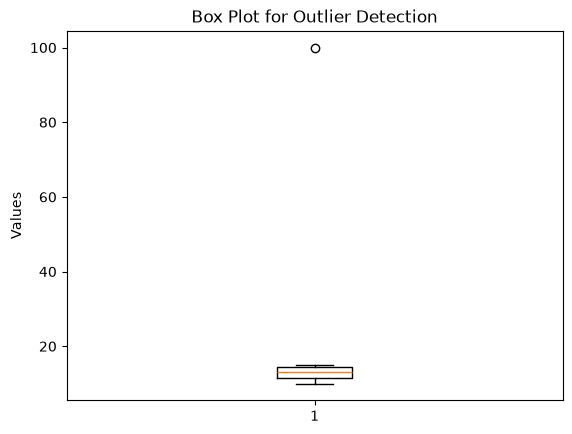

In [4]:
import matplotlib.pyplot as plt

data = [10, 11, 12, 13, 14, 15, 100]

plt.boxplot(data)
plt.title("Box Plot for Outlier Detection")
plt.ylabel("Values")
plt.show()

## 7. Scatter Plot

### Definition

A scatter plot displays the relationship between two numerical variables using points.

Scatter plots can help visually identify observations that are far away from the general pattern of the data.

### Example

Suppose most observations follow a relationship between study hours and exam scores, but one observation is very far from the general pattern.

That observation may be investigated as a potential outlier.

### AI/ML Example

Scatter plots are useful during Exploratory Data Analysis for identifying unusual observations, relationships, clusters, and patterns.

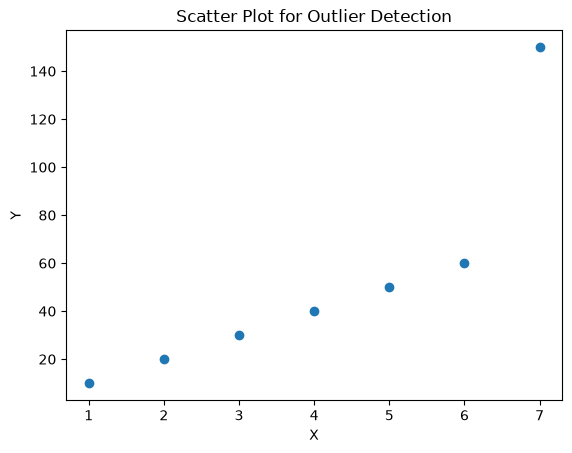

In [5]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5, 6, 7]
y = [10, 20, 30, 40, 50, 60, 150]

plt.scatter(x, y)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter Plot for Outlier Detection")

plt.show()

# IQR Method vs Z-Score Method

| IQR Method | Z-Score Method |
|---|---|
| Uses quartiles | Uses mean and standard deviation |
| IQR = Q3 - Q1 | Z = (x - mean) / standard deviation |
| Common cutoff is 1.5 × IQR | Common cutoff is absolute Z > 3 |
| Robust to extreme values | Sensitive to mean and standard deviation |
| Useful for skewed/non-normal data | Often useful for approximately normal data |

## Key Point

There is no single outlier detection method that is best for every dataset.

The method should be selected based on the distribution and context of the data.